In [39]:
import pandas as pd
import geopandas as gpd
from shapely import wkt
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
import networkx as nx
import kagglehub
import numpy as np

import shutil

import torch
from PIL import Image
from torchvision import transforms, models
from torchmetrics.image.fid import FrechetInceptionDistance
from prdc import compute_prdc 

# MSD REPOSITORY IMPORTS 
import plot
from constants import ROOM_MAPPING, ROOM_NAMES, CMAP_ROOMTYPE, ROOM_NAMES, COLORS_ROOMTYPE

# Dataset

**Load data**

In [2]:
dataset_folder = kagglehub.dataset_download("caspervanengelenburg/modified-swiss-dwellings")
path = os.path.join(dataset_folder, "mds_V2_5.372k.csv")
df = pd.read_csv(path, sep=',')

with open('train_indices.txt', 'r') as f:
    train_ids = [int(line.strip()) for line in f if line.strip()]

with open('test_indices.txt', 'r') as f:
    test_ids = [int(line.strip()) for line in f if line.strip()]

df['split'] = 'unknown'

df.loc[df['floor_id'].isin(train_ids), 'split'] = 'train'
df.loc[df['floor_id'].isin(test_ids), 'split'] = 'test'

print("Distribution of the split in train/test/unkown:")
print(df['split'].value_counts())



Distribution of the split in train/test/unkown:
split
train    925260
test     161586
Name: count, dtype: int64


In [3]:
df

,Unnamed: 0.1,Unnamed: 0,apartment_id,site_id,building_id,plan_id,floor_id,unit_id,area_id,unit_usage,entity_type,entity_subtype,geom,elevation,height,zoning,roomtype,split
0,0,0,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619311.0,RESIDENTIAL,area,BATHROOM,POLYGON ((-2.7337844078265210 4.07980744083215...,0.0,2.6,Zone3,Bathroom,train
1,1,1,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619303.0,RESIDENTIAL,area,LIVING_ROOM,POLYGON ((5.8278988701887320 7.816876723402971...,0.0,2.6,Zone2,Livingroom,train
2,2,2,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619322.0,RESIDENTIAL,area,ROOM,POLYGON ((6.7557107205191187 2.413369594812586...,0.0,2.6,Zone1,Bedroom,train
3,3,3,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619310.0,RESIDENTIAL,area,KITCHEN,POLYGON ((3.5821200013910017 5.140461688341117...,0.0,2.6,Zone2,Kitchen,train
4,4,4,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619312.0,RESIDENTIAL,area,ROOM,POLYGON ((3.0141380455489282 4.182056855151666...,0.0,2.6,Zone1,Bedroom,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1086841,1175252,1175252,NaN,855,1810,5103,8035,NaN,NaN,PUBLIC,opening,DOOR,POLYGON ((-1.4298320523458550 3.33190316001201...,14.5,2.0,Door,Door,test
1086842,1175253,1175253,NaN,855,1810,5103,8035,NaN,NaN,PUBLIC,opening,ENTRANCE_DOOR,POLYGON ((-3.5023200042238898 3.33190316001201...,14.5,2.0,Entrance Door,Entrance Door,test
1086843,1175254,1175254,NaN,855,1810,5103,8035,NaN,NaN,PUBLIC,opening,WINDOW,POLYGON ((0.5283550488528448 5.786336039980051...,15.0,1.9,Window,Window,test
1086844,1175255,1175255,NaN,855,1810,5103,8035,NaN,NaN,PUBLIC,opening,WINDOW,POLYGON ((-3.6279253346407394 5.80601415589792...,15.0,1.9,Window,Window,test


Each row in the dataset represents an architectural element. Below is the detailed description of each field:

| Column | Description |
| --- | --- |
| `apartment_id` | The ID of the apartment (note: an apartment ID is only unique per site). |
| `site_id` | The ID of the site. |
| `building_id` | The ID of the building. |
| `floor_id` | The ID of the floor. |
| `plan_id` | The ID of the plan on which the floor is based (multiple floors might share the same plan). |
| `unit_id` | The ID of the unit in which the element is spatially contained. |
| `area_id` | The ID of the area in which the element is spatially contained. |
| `unit_usage` | The usage of the unit: `RESIDENTIAL`, `COMMERCIAL`, `PUBLIC`, `JANITOR`. |
| `entity_type` | The entity type: `area`, `separator`, `opening`, `feature`. |
| `entity_subtype` | The entity’s sub-type (e.g., `WALL`). |
| `geometry` | The element’s geometry as a **WKT** (Well-Known Text) string in meters. |
| `elevation` | The object's elevation above the terrain surface in meters. |
| `height` | The height of the entity in meters. |


*Source: [Zenodo - Modified Swiss Dwellings*](https://zenodo.org/records/7788422)


**Drop columns and rows**

In [4]:
cols_to_drop = ['Unnamed: 0.1', 'Unnamed: 0']

df = df.drop(columns=cols_to_drop)
df

,apartment_id,site_id,building_id,plan_id,floor_id,unit_id,area_id,unit_usage,entity_type,entity_subtype,geom,elevation,height,zoning,roomtype,split
0,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619311.0,RESIDENTIAL,area,BATHROOM,POLYGON ((-2.7337844078265210 4.07980744083215...,0.0,2.6,Zone3,Bathroom,train
1,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619303.0,RESIDENTIAL,area,LIVING_ROOM,POLYGON ((5.8278988701887320 7.816876723402971...,0.0,2.6,Zone2,Livingroom,train
2,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619322.0,RESIDENTIAL,area,ROOM,POLYGON ((6.7557107205191187 2.413369594812586...,0.0,2.6,Zone1,Bedroom,train
3,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619310.0,RESIDENTIAL,area,KITCHEN,POLYGON ((3.5821200013910017 5.140461688341117...,0.0,2.6,Zone2,Kitchen,train
4,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619312.0,RESIDENTIAL,area,ROOM,POLYGON ((3.0141380455489282 4.182056855151666...,0.0,2.6,Zone1,Bedroom,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1086841,NaN,855,1810,5103,8035,NaN,NaN,PUBLIC,opening,DOOR,POLYGON ((-1.4298320523458550 3.33190316001201...,14.5,2.0,Door,Door,test
1086842,NaN,855,1810,5103,8035,NaN,NaN,PUBLIC,opening,ENTRANCE_DOOR,POLYGON ((-3.5023200042238898 3.33190316001201...,14.5,2.0,Entrance Door,Entrance Door,test
1086843,NaN,855,1810,5103,8035,NaN,NaN,PUBLIC,opening,WINDOW,POLYGON ((0.5283550488528448 5.786336039980051...,15.0,1.9,Window,Window,test
1086844,NaN,855,1810,5103,8035,NaN,NaN,PUBLIC,opening,WINDOW,POLYGON ((-3.6279253346407394 5.80601415589792...,15.0,1.9,Window,Window,test


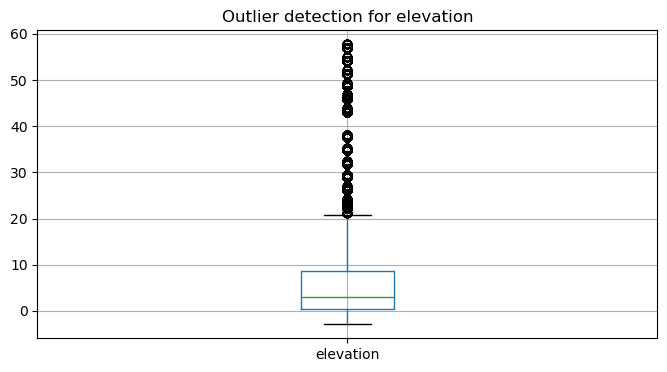

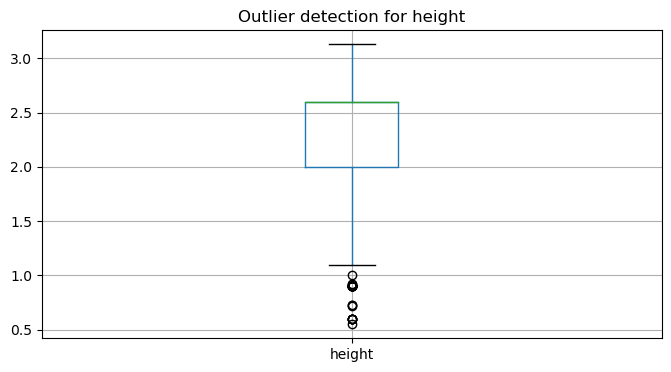

In [5]:
numerical_cols = ['elevation', 'height']

for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    df.boxplot(column=[col])
    plt.title(f'Outlier detection for {col}')
    plt.show()

In [6]:
df['roomtype'].unique()

array(['Bathroom', 'Livingroom', 'Bedroom', 'Kitchen', 'Balcony',
       'Corridor', 'Structure', 'Door', 'Window', 'Entrance Door',
       'Dining', 'Stairs', 'Storeroom'], dtype=object)

In [7]:
print(df.isna().sum())

apartment_id      193367
site_id                0
building_id            0
plan_id                0
floor_id               0
unit_id           193367
area_id           883516
unit_usage             0
entity_type            0
entity_subtype         0
geom                   0
elevation              0
height                 0
zoning                 0
roomtype               0
split                  0
dtype: int64


**Convert to geopandas**

In [8]:
df['geom'] = df['geom'].apply(wkt.loads)
gdf = gpd.GeoDataFrame(df, geometry='geom')
gdf

,apartment_id,site_id,building_id,plan_id,floor_id,unit_id,area_id,unit_usage,entity_type,entity_subtype,geom,elevation,height,zoning,roomtype,split
0,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619311.0,RESIDENTIAL,area,BATHROOM,"POLYGON ((-2.73378 4.07981, -1.7053 5.30551, -...",0.0,2.6,Zone3,Bathroom,train
1,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619303.0,RESIDENTIAL,area,LIVING_ROOM,"POLYGON ((5.8279 7.81688, 3.64914 5.22033, 0.4...",0.0,2.6,Zone2,Livingroom,train
2,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619322.0,RESIDENTIAL,area,ROOM,"POLYGON ((6.75571 2.41337, 6.42279 2.69272, 5....",0.0,2.6,Zone1,Bedroom,train
3,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619310.0,RESIDENTIAL,area,KITCHEN,"POLYGON ((3.58212 5.14046, 1.60055 2.77892, -1...",0.0,2.6,Zone2,Kitchen,train
4,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619312.0,RESIDENTIAL,area,ROOM,"POLYGON ((3.01414 4.18206, 6.13291 1.56509, 3....",0.0,2.6,Zone1,Bedroom,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1086841,NaN,855,1810,5103,8035,NaN,NaN,PUBLIC,opening,DOOR,"POLYGON ((-1.42983 3.3319, -1.42983 3.37147, -...",14.5,2.0,Door,Door,test
1086842,NaN,855,1810,5103,8035,NaN,NaN,PUBLIC,opening,ENTRANCE_DOOR,"POLYGON ((-3.50232 3.3319, -3.50232 3.37147, -...",14.5,2.0,Entrance Door,Entrance Door,test
1086843,NaN,855,1810,5103,8035,NaN,NaN,PUBLIC,opening,WINDOW,"POLYGON ((0.52836 5.78634, 0.58111 5.78634, 0....",15.0,1.9,Window,Window,test
1086844,NaN,855,1810,5103,8035,NaN,NaN,PUBLIC,opening,WINDOW,"POLYGON ((-3.62793 5.80601, -3.62793 5.85877, ...",15.0,1.9,Window,Window,test


**Perimeters**

In [9]:
# 1. Filter the entire dataset to keep only the rooms (areas)
all_rooms = df[df['entity_type'] == 'area'].copy()

# 2. Ensure it is a GeoDataFrame and set the geometry column
if not isinstance(all_rooms, gpd.GeoDataFrame):
    # Note: if 'geom' is pure text (WKT), you first need to convert it using shapely.wkt.loads
    # but assuming you already have valid geometry objects:
    all_rooms = gpd.GeoDataFrame(all_rooms, geometry='geom')

# 3. function that performs the contour
def generate_outline(room_geometries, wall_bridge_distance=0.3):
    return room_geometries.buffer(wall_bridge_distance).union_all().buffer(-wall_bridge_distance)

# 4. Apply the contour function to the whole dataset by grouping by 'unit_id'
print("Calculating all outlines... (this might take a few seconds)")
all_outlines = all_rooms.groupby('unit_id')['geom'].apply(generate_outline).reset_index()

# 5. Convert the result back into a clean GeoDataFrame
complete_outline_gdf = gpd.GeoDataFrame(all_outlines, geometry='geom')

print("Done! You have calculated the outlines for all apartments.")
complete_outline_gdf

Calculating all outlines... (this might take a few seconds)
Done! You have calculated the outlines for all apartments.


,unit_id,geom
0,4967.0,"POLYGON ((2.65476 5.19864, 2.6554 5.19901, 2.6..."
1,4969.0,"POLYGON ((-10.47718 4.67842, -10.47022 4.67937..."
2,4970.0,"POLYGON ((2.2429 5.52181, 2.25104 5.52657, 2.2..."
3,4971.0,"POLYGON ((-5.61788 -4.74761, -5.61092 -4.74665..."
4,4973.0,"POLYGON ((2.70623 5.21384, 2.71769 5.22048, 2...."
...,...,...
18897,161620.0,"POLYGON ((2.25378 0.04359, 2.25418 0.05061, 2...."
18898,161621.0,"POLYGON ((-6.4057 -3.56157, -6.4053 -3.55456, ..."
18899,161622.0,"POLYGON ((-11.45622 -3.02478, -11.45582 -3.017..."
18900,161623.0,"POLYGON ((2.25378 0.04359, 2.25418 0.05061, 2...."


**change name rooms**

In [10]:

ROOM_MAPPING = {
    'BATHROOM': 'Bathroom', 'LIVING_ROOM': 'Livingroom', 'LIVING_DINING': 'Livingroom',
    'ROOM': 'Bedroom', 'BEDROOM': 'Bedroom', 'KITCHEN': 'Kitchen',
    'KITCHEN_DINING': 'Kitchen', 'BALCONY': 'Balcony', 'TERRACE': 'Balcony',
    'CORRIDOR': 'Corridor', 'CORRIDORS_AND_HALLS': 'Corridor', 'WALL': 'Structure',
    'COLUMN': 'Structure', 'SHAFT': 'Structure', 'ELEVATOR': 'Structure',
    'VOID': 'Structure', 'DOOR': 'Door', 'ENTRANCE_DOOR': 'Front door',
    'WINDOW': 'Window', 'DINING': 'Dining', 'STAIRCASE': 'Stairs', 'STOREROOM': 'Storeroom'
}


ROOM_NAMES = list(set(ROOM_MAPPING.values()))


all_rooms['room_id'] = all_rooms['entity_subtype'].apply(
    lambda x: ROOM_NAMES.index(ROOM_MAPPING.get(x, 'Livingroom')) if ROOM_MAPPING.get(x, 'Livingroom') in ROOM_NAMES else 0
)




**Colors**

In [11]:

all_rooms['room_id'] = all_rooms['entity_subtype'].apply(
    lambda x: ROOM_NAMES.index(ROOM_MAPPING.get(x, 'Livingroom')) if ROOM_MAPPING.get(x, 'Livingroom') in ROOM_NAMES else 0
)


# Plot example

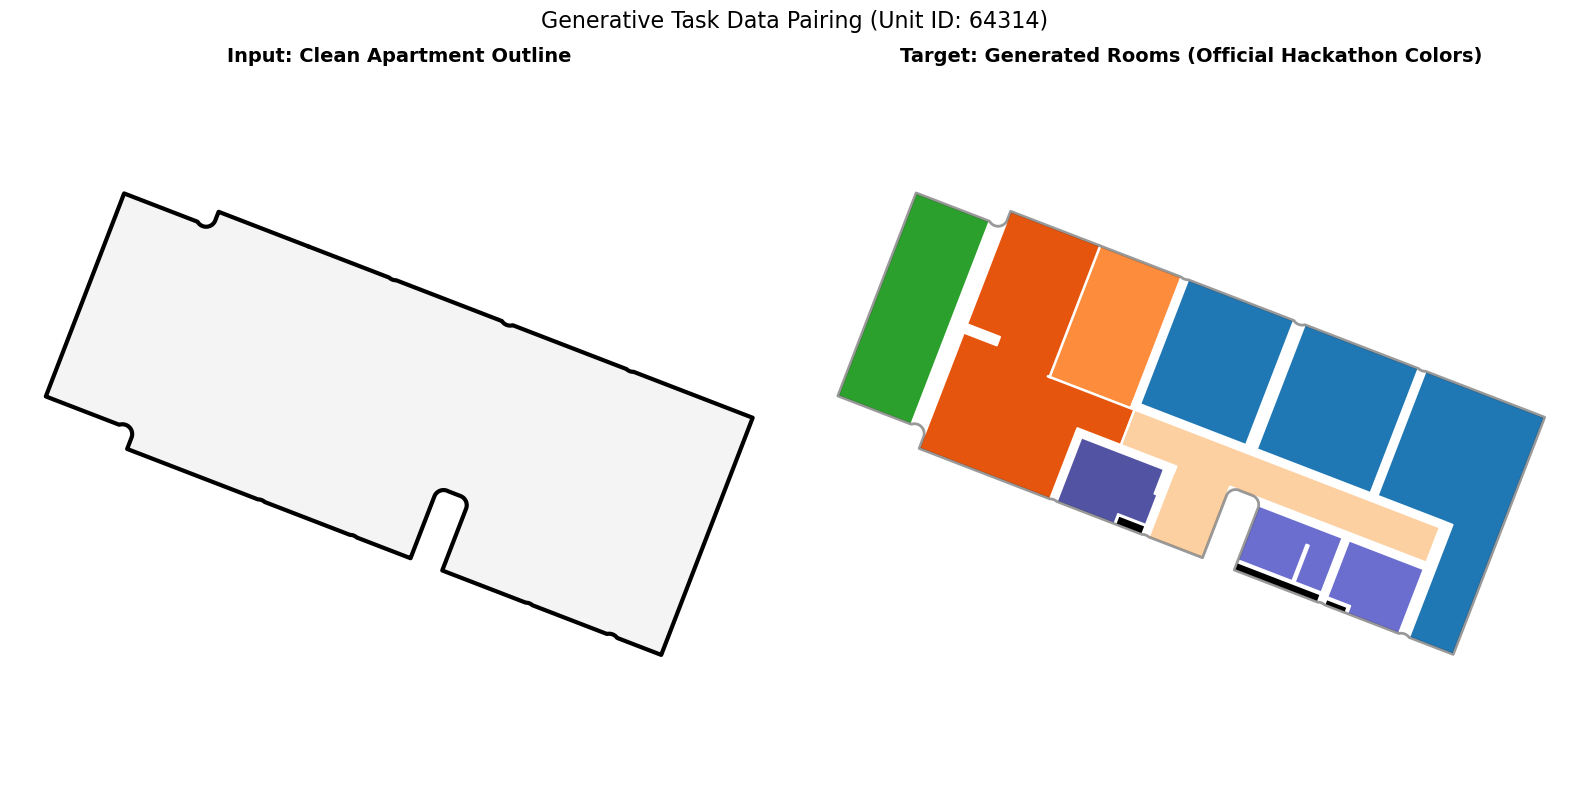

In [ ]:
sample_unit_id = 64314


rooms_to_plot = all_rooms[all_rooms['unit_id'] == sample_unit_id].copy()
outline_to_plot = complete_outline_gdf[complete_outline_gdf['unit_id'] == sample_unit_id]


rooms_to_plot['room_id'] = rooms_to_plot['entity_subtype'].apply(
    lambda x: ROOM_NAMES.index(ROOM_MAPPING.get(str(x).strip(), 'Livingroom')) if ROOM_MAPPING.get(str(x).strip(), 'Livingroom') in ROOM_NAMES else 0
)


rooms_to_plot['hex_color'] = rooms_to_plot['room_id'].apply(lambda x: COLORS_ROOMTYPE[x])

# 4. PLOT
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))


outline_to_plot.plot(ax=ax1, facecolor='#f4f4f4', edgecolor='black', linewidth=3)
ax1.set_title("Input: Clean Apartment Outline", fontsize=14, fontweight='bold')
ax1.axis('equal')
ax1.axis('off')


rooms_to_plot.plot(ax=ax2, color=rooms_to_plot['hex_color'].tolist(), edgecolor='white', linewidth=1.5)
outline_to_plot.plot(ax=ax2, facecolor='none', edgecolor='black', linewidth=2, alpha=0.4)
ax2.set_title("Target: Generated Rooms (Official Hackathon Colors)", fontsize=14, fontweight='bold')
ax2.axis('equal')
ax2.axis('off')

plt.suptitle(f"Generative Task Data Pairing (Unit ID: {sample_unit_id})", fontsize=16)
plt.tight_layout()
plt.show()

# Model

# Rendering

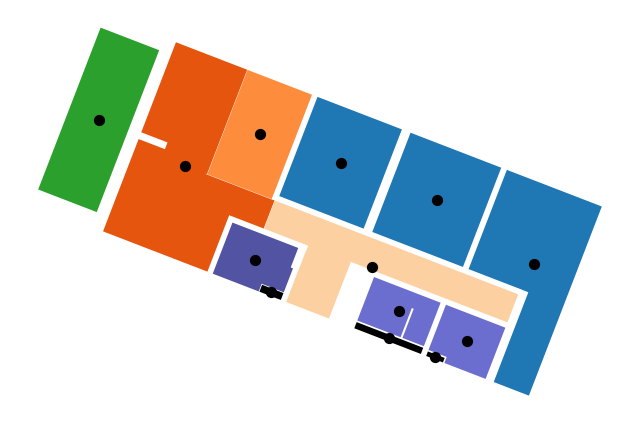

In [49]:
sample_unit_id = 64314
rooms_to_plot = all_rooms[all_rooms['unit_id'] == sample_unit_id]

def convert_to_msd_graph(single_apartment_gdf):
    G = nx.Graph()
    
    for i, (index, row) in enumerate(single_apartment_gdf.iterrows(), start=1):
        polygon = row['geom'] if 'geom' in single_apartment_gdf.columns else row.geometry
        centroid = (polygon.centroid.x, polygon.centroid.y)
        
        raw_room_name = row.get('entity_subtype', 'LIVING_ROOM') 
        mapped_room_name = ROOM_MAPPING.get(str(raw_room_name).strip(), 'Livingroom')
        room_id = ROOM_NAMES.index(mapped_room_name) if mapped_room_name in ROOM_NAMES else 0
            
        G.add_node(i, geometry=polygon, room_type=room_id, centroid=centroid)
        
    return G

graph_for_judges = convert_to_msd_graph(rooms_to_plot)

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect('equal') 
ax.axis('off')    

plot.plot_floor(graph_for_judges, ax=ax, node_size=50, edge_size=3)


plt.show()


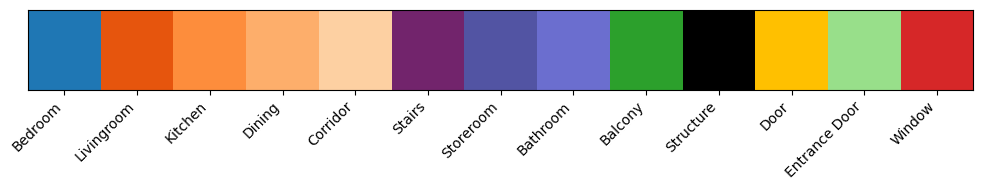

In [25]:

n_rooms = len(ROOM_NAMES)
gradient = np.linspace(0, 1, n_rooms)
gradient = np.vstack((gradient, gradient))

fig, ax = plt.subplots(figsize=(10, 2))
ax.imshow(gradient, aspect='auto', cmap=CMAP_ROOMTYPE)


ax.set_xticks(np.arange(n_rooms))
ax.set_xticklabels(ROOM_NAMES, rotation=45, ha='right')
ax.set_yticks([])

plt.tight_layout()
plt.show()

# Metrics

Starting rendering for 18903 apartments in 'evaluation_images/real'...


OSError: [Errno 28] No space left on device: 'evaluation_images/real/13899.0.png'

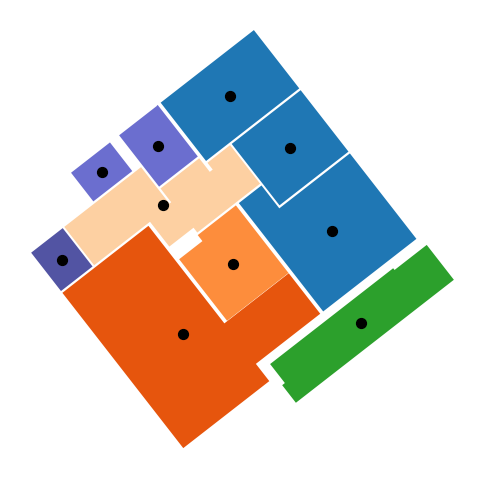

In [50]:
df_real = gdf.copy()

df_generated = df_real.copy() 


def save_rendering_batch(dataset_gdf, output_folder):

    if os.path.exists(output_folder):
        shutil.rmtree(output_folder)
    
    os.makedirs(output_folder, exist_ok=True)
    
    unit_ids = dataset_gdf['unit_id'].unique()
    print(f"Starting rendering for {len(unit_ids)} apartments in '{output_folder}'...")
    
    for unit_id in unit_ids:
        rooms_gdf = dataset_gdf[(dataset_gdf['unit_id'] == unit_id) & (dataset_gdf['entity_type'] == 'area')]
        
        if rooms_gdf.empty: 
            continue
            
        graph = convert_to_msd_graph(rooms_gdf)
        
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.set_aspect('equal')
        ax.axis('off')
        
        plot.plot_floor(graph, ax=ax, node_size=50, edge_size=3)
        
        fig.savefig(os.path.join(output_folder, f"{unit_id}.png"), bbox_inches='tight', pad_inches=0)
        plt.close(fig)
        
    print(f"Generation completed: images saved in '{output_folder}'.")

save_rendering_batch(df_real, "evaluation_images/real")
save_rendering_batch(df_generated, "evaluation_images/fake")

In [ ]:


REAL_DIR = "./evaluation_images/real"
FAKE_DIR = "./evaluation_images/fake"

# 1. Setup the visual extraction engine (InceptionV3)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load InceptionV3 and remove the final classification layer to get raw vectors (2048 values)
inception = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1)
inception.fc = torch.nn.Identity()
inception.eval().to(device)

# Standard preprocessing pipeline for Inception models
preprocess = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. "All-in-One" Function: Extracts PRDC vectors and updates FID simultaneously
def analyze_images(image_dir, fid_metric, is_real):
    features = []
    
    for filename in sorted(os.listdir(image_dir)):
        if not filename.endswith('.png'): continue
            
        # Load and convert image
        img = Image.open(os.path.join(image_dir, filename)).convert('RGB')
        
        # A. Update FID (requires a tensor between 0 and 1, without Inception normalization)
        img_fid = transforms.ToTensor()(img).unsqueeze(0)
        fid_metric.update(img_fid, real=is_real)
        
        # B. Extract feature vectors for PRDC
        with torch.no_grad():
            img_tensor = preprocess(img).unsqueeze(0).to(device)
            feat = inception(img_tensor).squeeze().cpu().numpy()
            features.append(feat)
            
    return np.array(features)

# 3. Execution & Calculation
print("Analyzing images...")
# Initialize the FID object
fid = FrechetInceptionDistance(feature=2048, normalize=True)

# Extract features for real and fake images
real_feats = analyze_images(REAL_DIR, fid, is_real=True)
fake_feats = analyze_images(FAKE_DIR, fid, is_real=False)

# --- PRINT FINAL RESULTS ---
print("\n=== EVALUATION RESULTS ===")

# Compute FID (Torchmetrics handles the math internally)
fid_score = fid.compute()
print(f"FID Score: {fid_score.item():.2f} (Lower is better)")

# Compute PRDC (k=5 is the scientific paper standard)
metrics = compute_prdc(real_features=real_feats, fake_features=fake_feats, nearest_k=5)
print(f"Density:   {metrics['density']:.4f} (Higher is better, ideally > 1)")
print(f"Coverage:  {metrics['coverage']:.4f} (Ranges from 0 to 1, higher is better)")

Analyzing images...

=== EVALUATION RESULTS ===
FID Score: -0.00 (Lower is better)
Num real: 49 Num fake: 49
Density:   1.0000 (Higher is better, ideally > 1)
Coverage:  1.0000 (Ranges from 0 to 1, higher is better)
